#### Predicting Heart Disease
- The project is focused on predicting the likelihood of a new patient having heart disease in the future.

In [1]:
import pandas as pd

In [3]:
heart_disease_df = pd.read_csv("heart_disease_prediction.csv")
print(heart_disease_df.head(5))
print(heart_disease_df.shape)

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
(918, 12)


#### EDA : Descriptive Statistics
https://docs.graphite-note.com/graphite-note-documentation/understanding-machine-learning/machine-learning-concepts/exploratory-data-analysis-eda

In [4]:
# to identify the numerical and categorical columns
# The categorical columns will be dtype object and numerical will be int64

print(heart_disease_df.dtypes)

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


In [5]:
# Descriptive statistics for the df
print(heart_disease_df.describe())

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


From above observation:
Average age of the patient is 53.51 years.

Features that stand out or seems sus are:
1. RestingBP min = 0, a living person cannot have blood pressure of 0.
2. Cholesterol minimum = 0, cannot realistically be 0
3. Oldpeak minimum = -2.6, negative values may or may not be valid.

From this summary, count = 918 for every column, that means there is no official missing (NaN) values, but may be there are hidden missing values.


#### EDA : Visualization

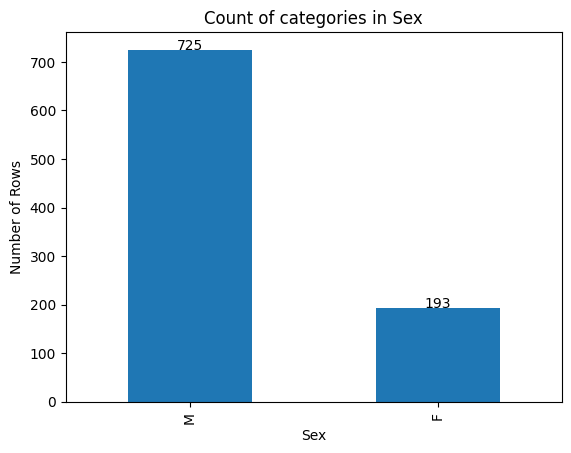

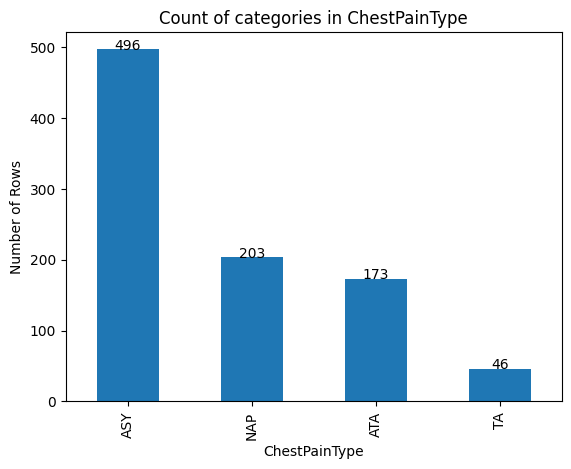

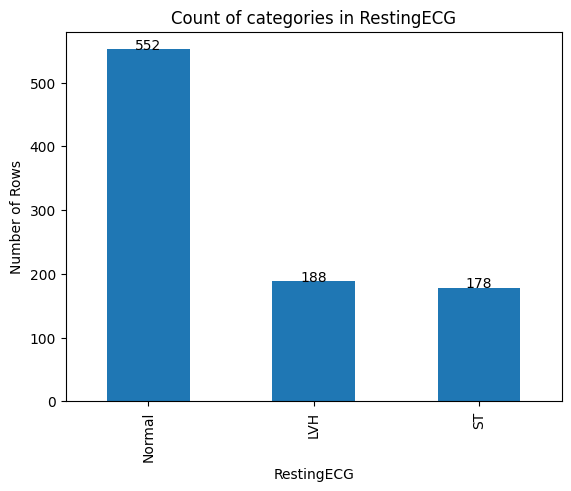

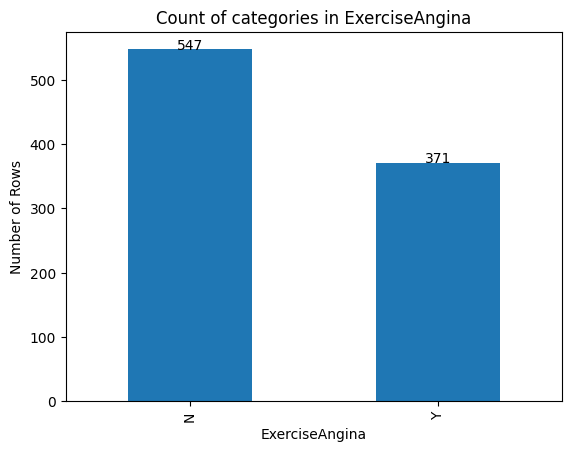

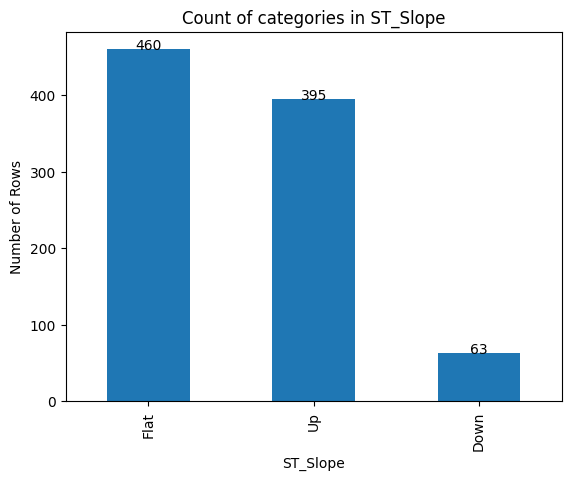

In [9]:
import matplotlib.pyplot as plt

# selecting categorical columns:
categorical_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

#creating bar chart for each categorical columns
for col in categorical_cols:
    counts = heart_disease_df[col].value_counts()
    ax = counts.plot(kind="bar")

    plt.xlabel(col)
    plt.ylabel("Number of Rows")
    plt.title(f"Count of categories in {col}")
    
    for i, value in enumerate(counts):
        plt.text(i, value, str(value), ha='center')

    plt.show()

Observations from above bar chart:
Sex Distribution:
- Male - 725
- Female - 193
The dataset is heavily dominated by male patients.

ChestPainType Distribution
- ASY(Asymptomatic) : 496 patients
- NAP: 203 patients
- ATA: 173 patients
- TA: 46 patients
Most patients have ASY chest pain type, many patients show heart disease symptoms without typical chest pain.
RestingECG Distribution
- Normal: 552 patients
- LVH: 188 patients
- ST: 178 patients
Most patients have normal resting ECG results.

Overall Observation:
The dataset is imbalanced toward males, contains many asymptomatic chest pain cases etc. These patterns may influence model behavior and predictions

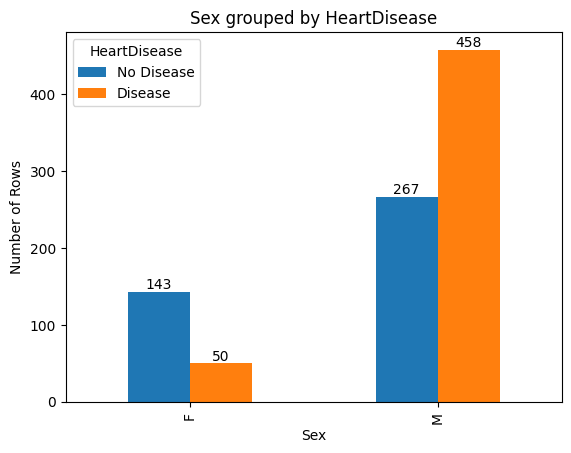

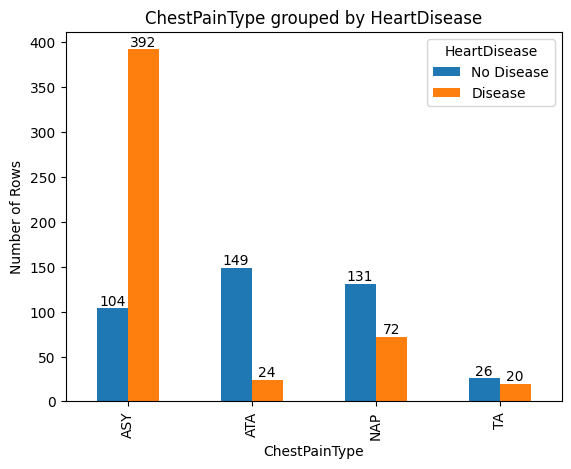

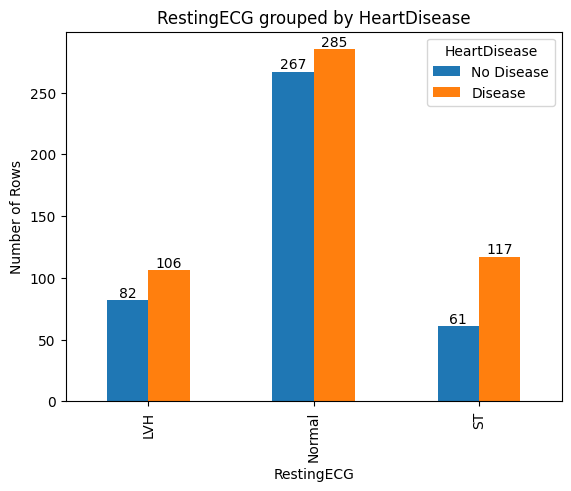

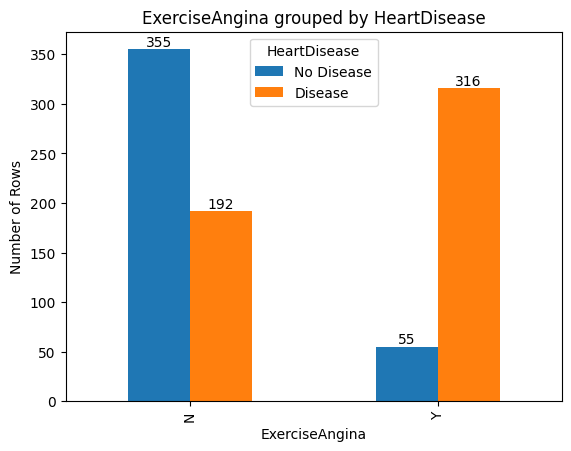

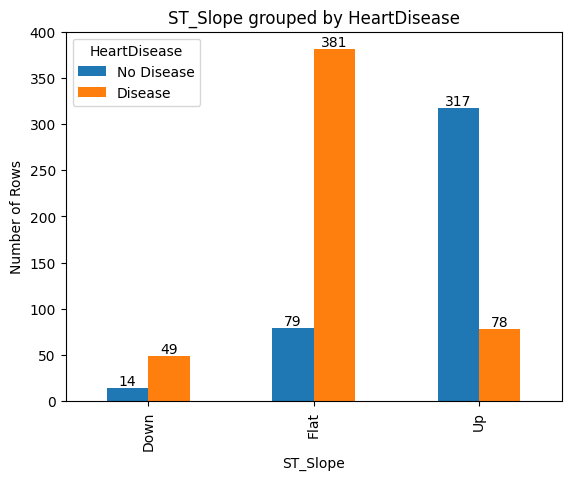

In [10]:
# creating grouped bar charts
for col in categorical_cols:
    grouped_counts = heart_disease_df.groupby(
        [col, "HeartDisease"]
    ).size().unstack()

    ax = grouped_counts.plot(kind="bar")

    plt.xlabel(col)
    plt.ylabel("Number of Rows")
    plt.title(f"{col} grouped by HeartDisease")

    plt.legend(
        title = "HeartDisease",
        labels=["No Disease", "Disease"]
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.show()

### Data Cleaning